In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from math import sin
from scipy.integrate import solve_ivp
import math

# utils
from utils.saveFig import img_save
from utils.metrics import metrics



In [2]:
# ==========================================
# 1. Parâmetros Biológicos do Sistema
# ==========================================
mu_m = 0.5   # h^-1
ks = 0.1     # g/L
Y = 0.4      # g/g

# ==========================================
# 2. Ponto de Equilíbrio Analítico (Ponto II)
# ==========================================
D0 = 0.35
sf0 = 1.0    # g/L
s0 = 7/30    # ~0.2333 g/L
x0 = 23/75   # ~0.3067 g/L

# Matrizes Linearizadas (F e G exatas calculadas anteriormente)
F = np.array([[0.0,     0.138],
              [-0.875, -0.695]])

# G agora é CORRETAMENTE definida como uma matriz 2x2 (MIMO)
# Primeira coluna: derivadas em relação a D
# Segunda coluna: derivadas em relação a sf
G = np.array([[-x0,       0.0],
              [sf0 - s0,  D0 ]])

In [3]:

# ==========================================
# 3. Definição do Vetor de Entrada (u)
# ==========================================
def u_input(t):
    """
    Retorna os valores reais e os desvios das duas entradas no instante t.
    u_real = [D_real, sf_real]
    delta_u = [delta_D, delta_sf]
    """
    # Degrau de +10% na vazão da bomba (D) em t = 10h
    delta_D = 0.035 if t >= 10.0 else 0.0
    
    # Para demonstrar o MIMO, vamos aplicar também um degrau 
    # na alimentação (sf) em t = 25h
    delta_sf = -0.1 if t >= 25.0 else 0.0 
    
    # Valores absolutos que vão para o modelo não linear
    D_real = D0 + delta_D
    sf_real = sf0 + delta_sf
    
    # Retorna os vetores [D, sf]
    return np.array([D_real, sf_real]), np.array([delta_D, delta_sf])

# ==========================================
# 4. Equações Diferenciais
# ==========================================
def sistema_nao_linear(X, t):
    """Modelo real completo do biorreator (Não Linear)"""
    x, s = X
    
    # Extrai o vetor u_real [D_real, sf_real]
    u_real, _ = u_input(t)
    D_real = u_real[0]
    sf_real = u_real[1]
    
    # Função de Monod
    mu = (mu_m * s) / (ks + s)
    
    # Balanço de massa (Não Linear)
    dx_dt = mu * x - D_real * x
    ds_dt = D_real * (sf_real - s) - (mu / Y) * x
    
    return [dx_dt, ds_dt]

def sistema_linearizado(delta_X, t):
    """Modelo de pequenos sinais (Linearizado MIMO)"""
    # Extrai o vetor delta_u [delta_D, delta_sf]
    _, delta_u = u_input(t)
    
    # d(delta_X)/dt = F * delta_X + G * delta_u
    # Agora usamos produto matricial F.dot() e G.dot() para matriz 2x2 * vetor 2x1
    d_delta_X = F.dot(delta_X) + G.dot(delta_u)
    
    return d_delta_X


=== Validação da linearização ===
Norma relativa do erro em x: 1.76%
Erro máximo em x: 0.00834
Validade em x até: 50 h
=== Validação da linearização ===
Norma relativa do erro em s: 3.81%
Erro máximo em s: 0.02085
Validade em s até: 43 h


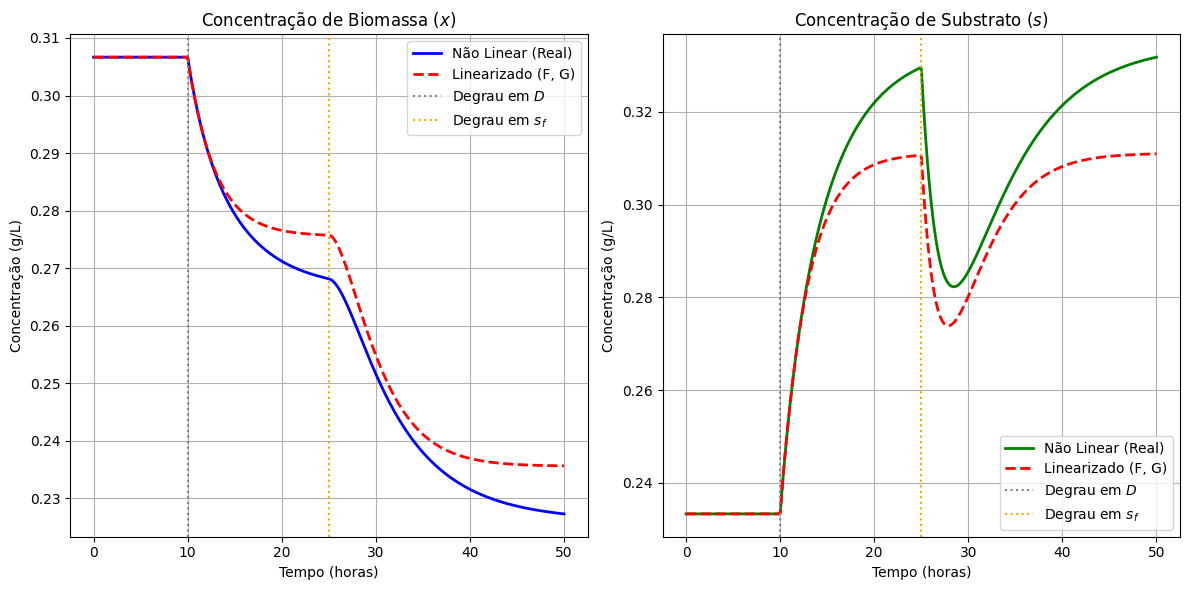

Imagem salva em: c:\Users\ander\Desktop\Sistemas inteligentes\imgs\AnaliseLinear\Analise Linear.png


In [5]:


# ==========================================
# 5. Simulação
# ==========================================
tempo = np.linspace(0, 50, 1000) # Simula de 0 a 50 horas

# Condições Iniciais: Ambos começam exatamente no ponto nominal
X_inicial_nao_linear = [x0, s0]
X_inicial_linear = [0.0, 0.0] # Desvio inicial é zero!

# Resolvendo as EDOs
# sol_nao_linear = solve_ivp(sistema_nao_linear,t_span=(tempo[0], tempo[-1]),y0=X_inicial_nao_linear,t_eval=tempo,method="RK45",max_step=0.05)
# sol_linear = solve_ivp(sistema_linearizado,t_span=(tempo[0], tempo[-1]),y0=X_inicial_linear,t_eval=tempo,method="RK45",max_step=0.05)
X_nao_linear = odeint(sistema_nao_linear, X_inicial_nao_linear, tempo)
X_linearizado_desvios = odeint(sistema_linearizado, X_inicial_linear, tempo)


# X_nao_linear = sol_nao_linear.y.T
# X_linearizado_desvios = sol_linear.y.T

# Para comparar, precisamos somar o ponto de equilíbrio aos desvios
x_linear_absoluto = x0 + X_linearizado_desvios[:, 0]
s_linear_absoluto = s0 + X_linearizado_desvios[:, 1]

# Extraindo os estados do não linear para plotagem
x_nao_linear = X_nao_linear[:, 0]
s_nao_linear = X_nao_linear[:, 1]

# métricas adicionais:
metrics(x_nao_linear, x_linear_absoluto, tempo, "x")
metrics(s_nao_linear, s_linear_absoluto, tempo, "s")

# ==========================================
# 6. Plotagem dos Gráficos
# ==========================================
plt.figure(figsize=(12, 6))

# Gráfico da Biomassa (X)
plt.subplot(1, 2, 1)
plt.plot(tempo, x_nao_linear, 'b-', linewidth=2, label='Não Linear (Real)')
plt.plot(tempo, x_linear_absoluto, 'r--', linewidth=2, label='Linearizado (F, G)')
plt.axvline(x=10, color='gray', linestyle=':', label='Degrau em $D$')
plt.axvline(x=25, color='orange', linestyle=':', label='Degrau em $s_f$')
plt.title('Concentração de Biomassa ($x$)')
plt.xlabel('Tempo (horas)')
plt.ylabel('Concentração (g/L)')
plt.legend()
plt.grid(True)

# Gráfico do Substrato (S)
plt.subplot(1, 2, 2)
plt.plot(tempo, s_nao_linear, 'g-', linewidth=2, label='Não Linear (Real)')
plt.plot(tempo, s_linear_absoluto, 'r--', linewidth=2, label='Linearizado (F, G)')
plt.axvline(x=10, color='gray', linestyle=':', label='Degrau em $D$')
plt.axvline(x=25, color='orange', linestyle=':', label='Degrau em $s_f$')
plt.title('Concentração de Substrato ($s$)')
plt.xlabel('Tempo (horas)')
plt.ylabel('Concentração (g/L)')
plt.legend()
plt.grid(True)

plt.tight_layout()
img_save(file_name="Analise Linear", dir_name="AnaliseLinear")
